In [1]:
%load_ext autotime
%load_ext autoreload
%autoreload 2

time: 11.6 ms (started: 2025-05-15 21:27:44 +08:00)


In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, PowerNorm
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.patheffects as path_effects
import os
import sys
from scipy import stats
from sunpy.coordinates import frames
import sunpy.map
from sunpy.net import Fido
from sunpy.net import attrs as a
import pickle

time: 2.58 s (started: 2025-05-15 21:27:55 +08:00)


In [5]:
with open('fig2_data.pkl', 'rb') as f:
    loaded_fig2_data = pickle.load(f)
fi_ref_list = loaded_fig2_data['fi_ref_list']
fi_gen_list = loaded_fig2_data['fi_gen_list']
sj_ref_list = loaded_fig2_data['sj_ref_list']
sj_gen_list = loaded_fig2_data['sj_gen_list']

time: 27.5 ms (started: 2025-05-15 21:33:25 +08:00)


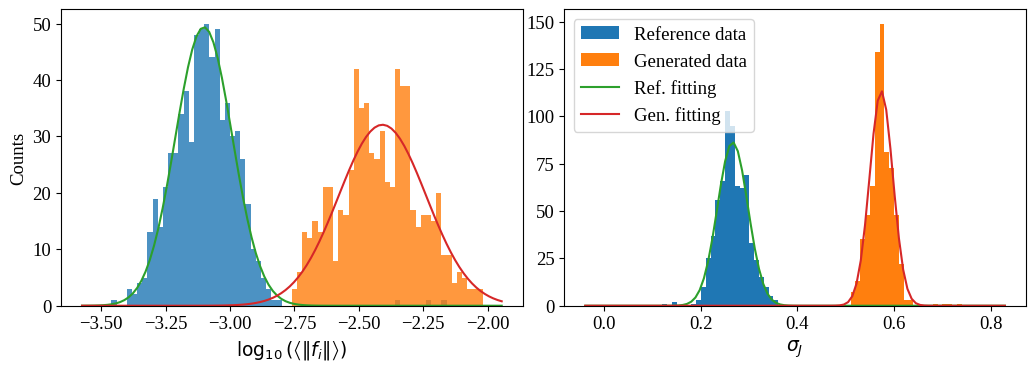

time: 1.95 s (started: 2025-05-15 21:40:20 +08:00)


In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import numpy as np
from PIL import Image
from scipy import stats



# 设置参数
zoom_factor = 1.5
plt.rcParams['font.size'] = 9.0 * zoom_factor
plt.rcParams['font.family'] = 'Liberation Serif'
A4_width = 8.3 * zoom_factor
A4_length = 11.7 * zoom_factor
golden_ratio = 0.618

plt.figure(figsize = (A4_width, A4_width*golden_ratio/2))
plt.subplot(121)
bins = np.arange(-3.5,-2.0,0.02)
plt.hist(np.log10(fi_ref_list), bins=bins, alpha=0.8, label='Reference data')
plt.hist(np.log10(fi_gen_list), bins=bins, alpha=0.8, label='Generated data')
xmin, xmax = plt.gca().get_xlim()
x = np.linspace(xmin, xmax, 100)
log_fi_ref = np.log10(fi_ref_list)
q1, q3 = np.percentile(log_fi_ref, [25, 75])
iqr = q3 - q1
valid_mask = (log_fi_ref >= q1 - 1.5*iqr) & (log_fi_ref <= q3 + 1.5*iqr)
mu1, std1 = stats.norm.fit(log_fi_ref[valid_mask])
mu2, std2 = stats.norm.fit(np.log10(fi_gen_list))
plt.plot(x,stats.norm.pdf(x, mu1, std1)*len(fi_ref_list)*0.02,label='Ref. fitting')
plt.plot(x,stats.norm.pdf(x, mu2, std2)*len(fi_gen_list)*0.02,label='Gen. fitting')
plt.xlabel(r'$\log_{10}(\left<\|f_i\|\right>)$')
plt.ylabel('Counts')

plt.subplot(122)
bins = np.arange(0, 0.8, 0.01)
plt.hist(sj_ref_list, bins=bins, label='Reference data')
plt.hist(sj_gen_list, bins=bins, label='Generated data')
xmin, xmax = plt.gca().get_xlim()
x = np.linspace(xmin, xmax, 100)
mu3, std3 = stats.norm.fit(sj_ref_list)
mu4, std4 = stats.norm.fit(sj_gen_list)
plt.plot(x, stats.norm.pdf(x, mu3, std3) * len(sj_ref_list) * 0.01, label='Ref. fitting')
plt.plot(x, stats.norm.pdf(x, mu4, std4) * len(sj_gen_list) * 0.01, label='Gen. fitting')
plt.xlabel(r'$\sigma_{J}$')
plt.legend()

plt.subplots_adjust(wspace=0.09)
plt.savefig('fig2.png', dpi=400, bbox_inches='tight')
plt.savefig('fig2.pdf', dpi=400, bbox_inches='tight')
plt.show()